In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pingouin as pg
from myFigures import *

from scipy import stats
import statsmodels.formula.api as smf
from pymer4.models import Lmer, Lm
import statsmodels  as sm
import os
from statsmodels.stats.anova import AnovaRM



from pymer4.io import save_model, load_model

In [2]:
PROJECT_PATH = "/media/wiseman/tocho/predrelv_fmri/"
DATA_PATH = f"{PROJECT_PATH}/group_analyses/multivariate/MVPA_proba/analyses/decoding_data/"
ROI = "earlyvisual"
N_VOXELS = "wholeROI"

# Modeling each subject + univariate ROIs

### functions

In [3]:
from itertools import product

def generate_artificial_data(dat, subj, predictors, univariate_ROI, z_scores):
    """
    Generate artificial data for a given subject and ROI.
    This function generates a dataframe with all possible combinations of predictor values
    for a given subject and ROI. The z_scores are repeated for each combination.
    """
    
    artificial_df = {pred: [] for pred in predictors}
    artificial_df["id"] = []
    artificial_df[univariate_ROI] = []
    artificial_df["z_score"] = []  # Add a new column for z_scores

    # Get unique values for each predictor
    unique_values = {pred: dat[pred].unique() for pred in predictors if pred != univariate_ROI}

    # Generate all combinations of predictor values
    for combination in product(*unique_values.values()):
        artificial_df["id"].extend([subj] * len(z_scores))
        for pred, value in zip(unique_values.keys(), combination):
            artificial_df[pred].extend([value] * len(z_scores))
        artificial_df[univariate_ROI].extend(z_scores)
        artificial_df["z_score"].extend(z_scores)  # Add z_scores for each combination

    return pd.DataFrame(artificial_df)

In [4]:
def subject_GLMs(dat, id, univariate_ROI, model_formula, predictors, family="gaussian"):
    """
    This function fits a GLM for each subject in the dataset, including univariate ROI activity as an additional
    continuous predictor. The function returns a dataframe with predicted probabilities for each subject, as well
    as a dataframe with model coefficients, standard errors, z-values, and p-values.
    """
    # Placeholder for predictions and coefficients
    all_preds = []
    coefficients_list = []

    # Loop through each subject
    for subj in dat[id].unique():
        subj_data = dat[dat[id] == subj].copy()  # Copy to avoid warnings

        # Fit logistic regression separately for each subject
        try:
            if family == "gaussian":
                model = smf.ols(
                    f"{model_formula}",  # classified_stim ~ expected_stim * a_pred + expected_stim:a_pred:{univariate_ROI}",
                    data=subj_data,
                ).fit()  # _regularized(alpha=0.01, method="l1")  # Suppress warnings
            elif family == "binomial":
                model = smf.logit(
                    f"{model_formula}",  # classified_stim ~ expected_stim * a_pred + expected_stim:a_pred:{univariate_ROI}",
                    data=subj_data,
                ).fit()  # _regularized(alpha=0.01, method="l1")  # Suppress warnings

            # Predict probabilities on artificial data
            # create artificial dataframe
            z_scores = list(np.linspace(-4, 4, 500))

            artificial_df = generate_artificial_data(
                dat, subj, predictors, univariate_ROI, z_scores
            )

            artificial_df["predicted_prob"] = model.predict(artificial_df)
            artificial_df = pd.DataFrame(artificial_df)

            # Append results
            all_preds.append(artificial_df)

            # Store model coefficients, standard errors, z-values, and p-values
            coef_df = pd.DataFrame(
                {
                    "term": model.params.index,
                    "coefficient": model.params.values,
                    "std_error": model.bse.values,
                    "z_value": model.tvalues.values,
                    "p_value": model.pvalues.values,
                    "subject": subj,
                }
            )

            coefficients_list.append(coef_df)

        except Exception as e:
            print(f"Skipping subject {subj} due to convergence issues: {e}")

    # Combine all subject predictions and coefficients into DataFrames
    predicted_df = pd.concat(all_preds, ignore_index=True)
    coefficients_df = pd.concat(coefficients_list, ignore_index=True)

    return predicted_df, coefficients_df

## Load data

In [5]:
# The dataframe with all trials will be used to fit regression models with trial by trial measures
# The reason for this is that before fitting we need to aggreggate the data of each trial across permutations
# This can't be done with the balanced data, as it requires to have different sets of trials at each permutation
alltrials_df = pd.read_csv(f"{DATA_PATH}/{ROI}_{N_VOXELS}/balanced_group_data.csv") 
            
alltrials_df["correct"] = alltrials_df["correct"].astype(int)
alltrials_df["pred"] = alltrials_df["pred"].astype(str)
alltrials_df["ign_pred"] = alltrials_df["ign_pred"].astype(str)
alltrials_df["v_pred"] = np.where(alltrials_df["modality"] == "visual", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["a_pred"] = np.where(alltrials_df["modality"] == "auditory", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype(str)
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype(str)
alltrials_df["expected_stim"] = np.where(alltrials_df["expected_stim"] == 0, "CW", "CCW")
alltrials_df["stim"] = np.where(alltrials_df["stim"] == 0, "CW", "CCW")

# Aggregate across perms, while retaining important columns
alltrials_df = alltrials_df.groupby(['subj', 'run', 'trial']).agg(
    correct=('correct', 'mean'), 
    modality=('modality', 'first'),
    v_pred=('v_pred', 'first'),
    a_pred=('a_pred', 'first'),
    v_learned=('v_learned', 'first'),
    a_learned=('a_learned', 'first'),
    classified_stim=('classified_stim', 'mean'),
    stim = ('stim', 'first'),
    expected_stim=('expected_stim', 'first'),
    z_distance=('z_distance', 'mean'),
    decision_distances=('decision_distances', 'mean'),
    prob_0=('prob_0', 'mean'),
    prob_1=('prob_1', 'mean'),
    bilateral_HC = ('bilateralHC', 'first'), # for ROI avg beta, we can take the first value as it is the same for all trials
    subiculum = ('subiculum', 'first'),
    CA1 = ('CA1', 'first'),
    CA3 = ('CA3', 'first'),
    GC_DG = ('GC_DG', 'first'),
    CA3DG = ('CA3DG', 'first'),
).reset_index()

df = alltrials_df.copy()

# Binarize the 'correct' column
df['correct'] = df['correct'].round()

# defining columns as categorical
df["stim"] = df["stim"].astype('category')
df["modality"] = df["modality"].astype('category')
df["v_pred"] = df["v_pred"].astype('category')
df["a_pred"] = df["a_pred"].astype('category')
df["expected_stim"] = df["expected_stim"].astype('category')

## Full model

In [17]:
univariate_ROI = "CA1"
id = "subj"
model_formula = f"prob_1 ~ stim * expected_stim * a_pred * {univariate_ROI}"
predictors = ["stim", "expected_stim", "a_pred", univariate_ROI]
dat = df[(df["modality"] == "visual")].copy()

predicted_df, coefficients_df = subject_GLMs(dat, id, univariate_ROI, model_formula, predictors, family="gaussian")

Skipping subject sub-22 due to convergence issues: zero-size array to reduction operation maximum which has no identity


/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:424: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby(id_col)[y].transform('mean')
/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:425: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:427: SettingWithCopyWarning: 
A v

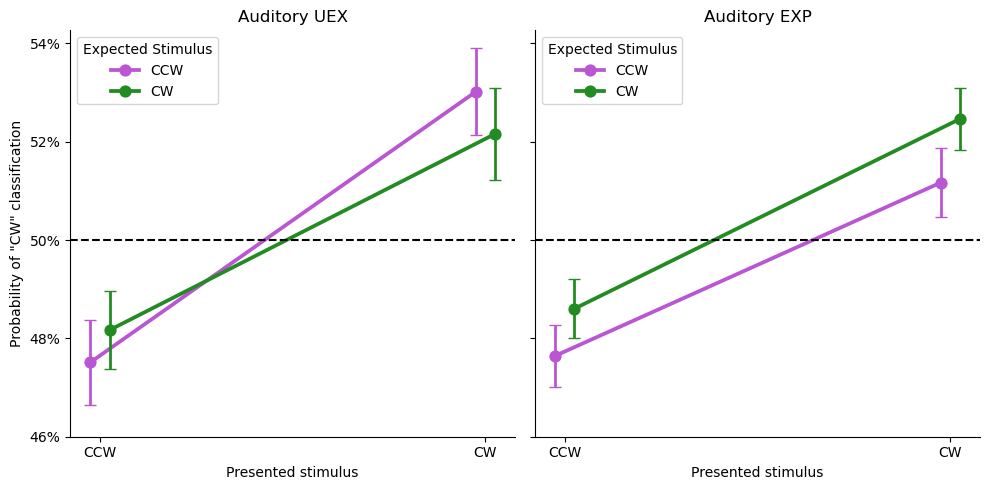

In [18]:
id = "id"
x = "stim"
hue = "expected_stim"
y = "predicted_prob"
col = "a_pred"

# Group data
dat = predicted_df.groupby([id, x, hue, col])[y].mean().reset_index()


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
# plot x axis in order CCW, CW
# Loop through unique col levels
for i, col_level in enumerate(dat[col].unique()):
    pointplot_morey(dat[dat[col] == col_level], x, y, hue, id_col=id, swarmplot_plot=False, palette=["mediumorchid", "forestgreen"], dodge_width=0.05, hline = 0.5, ax=axes[i])
    exp_label="UEX" if col_level=="0" else "EXP"
    axes[i].set_title(f"Auditory {exp_label}")
    axes[i].legend().set_title("Expected Stimulus")
    axes[i].set_xlabel("Presented stimulus")
    axes[i].set_xticklabels(["CCW", "CW"])
    axes[i].set_ylabel(f'Probability of "CW" classification')
    axes[i].set_yticks(np.linspace(0.46, .54, 5))
    # Format y-axis as percentage rounded
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))



plt.tight_layout()  # Optional for better spacing
plt.show()



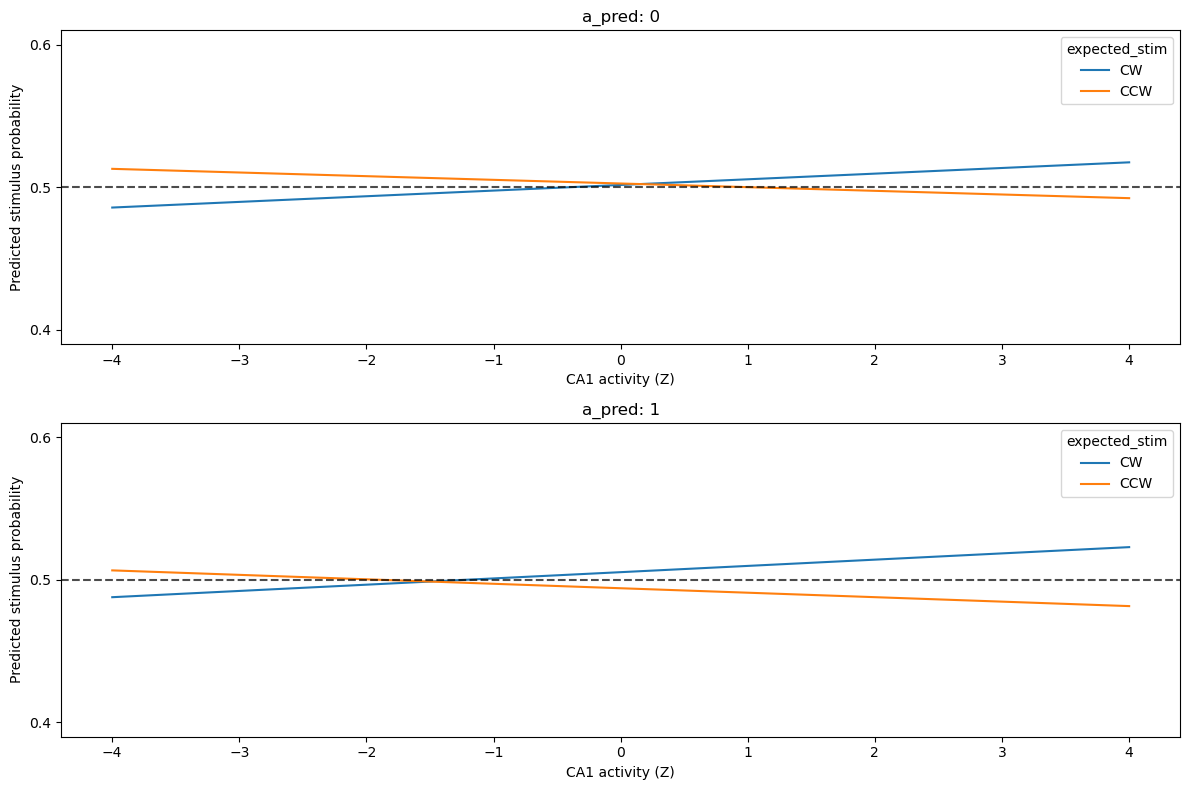

In [19]:
# Create a grid of subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Loop through unique values of a_pred
for i, a_pred in enumerate(predicted_df["a_pred"].unique()):
    ax = axes[i]  # Select the specific subplot

    # Plotting the data treating 'subiculum' as a continuous variable
    sns.lineplot(
        data=predicted_df[predicted_df["a_pred"] == a_pred],
        x=univariate_ROI,
        y="predicted_prob",
        hue="expected_stim",
        ci=None,  # Show standard deviation as confidence interval
        ax=ax
    )
    
    ax.axhline(0.5, ls="--", color="black", alpha=0.7)
    ax.set_title(f'a_pred: {a_pred}')  # Add titles
    ax.set_ylim(0.39, .61)  # Set y-axis limits
    ax.set_yticks([0.4, 0.5, 0.6])  # Set y-axis ticks
    ax.set_ylabel("Predicted stimulus probability")  # Add y-axis label
    ax.set_xlabel(f"{univariate_ROI} activity (Z)")  # Add x-axis label

plt.tight_layout()
plt.show()

## separately model by a_pred

### a_pred = 1

In [20]:
univariate_ROI = "subiculum"
id = "subj"
model_formula = f"prob_1 ~ expected_stim * {univariate_ROI}" #f"classified_stim ~ stim + expected_stim + stim:expected_stim + expected_stim:{univariate_ROI}"
predictors = ["stim", "expected_stim", univariate_ROI]
dat = df[(df["modality"] == "visual") & (df["a_pred"]=="1")].copy()

predicted_df, coefficients_df = subject_GLMs(dat, id, univariate_ROI, model_formula, predictors)

Skipping subject sub-22 due to convergence issues: zero-size array to reduction operation maximum which has no identity


In [12]:
coefficients_df

,term,coefficient,std_error,z_value,p_value,subject
0,Intercept,0.464164,0.019595,23.687728,7.937936e-51,sub-02
1,expected_stim[T.CW],0.097897,0.027607,3.546083,5.322767e-04,sub-02
2,subiculum,0.011947,0.021273,0.561588,5.752950e-01,sub-02
3,expected_stim[T.CW]:subiculum,-0.021139,0.027413,-0.771129,4.419303e-01,sub-02
4,Intercept,0.491499,0.009794,50.182226,2.222633e-91,sub-03
...,...,...,...,...,...,...
91,expected_stim[T.CW]:subiculum,-0.047600,0.017404,-2.735047,7.044401e-03,sub-26
92,Intercept,0.495799,0.007316,67.772388,6.357900e-109,sub-27
93,expected_stim[T.CW],0.015656,0.010284,1.522336,1.301805e-01,sub-27
94,subiculum,0.005099,0.006732,0.757503,4.500219e-01,sub-27


exp0: nan exp1: nan


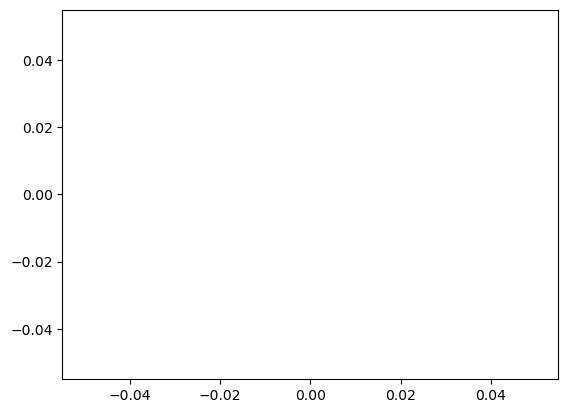

In [81]:
exp0 = coefficients_df[coefficients_df["term"]==f"expected_stim[0]:{univariate_ROI}"]
exp1 = coefficients_df[coefficients_df["term"]==f"expected_stim[1]:{univariate_ROI}"]
sns.histplot(exp0["coefficient"], bins=10)
plt.axvline(exp0["coefficient"].mean(), color='blue')
sns.histplot(exp1["coefficient"], bins=10)
plt.axvline(exp1["coefficient"].mean(), color='orange')


print("exp0:", exp0["coefficient"].mean(), "exp1:", exp1["coefficient"].mean())

In [82]:
stats.ttest_rel(exp0["coefficient"], exp1["coefficient"])

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

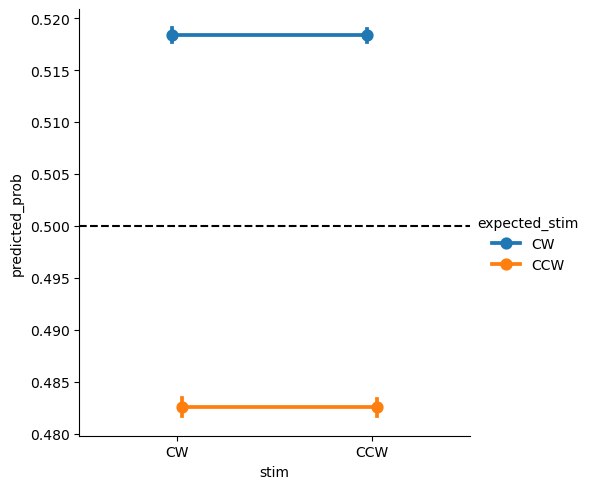

In [83]:
# Point plot with interactions
g = sns.catplot(
    data=predicted_df,
    x="stim",
    y="predicted_prob",
    hue="expected_stim",
    kind="point",
    dodge=True
)

# Add horizontal line at 0.5 
for ax in g.axes.flat:
    ax.axhline(0.5, ls='--', color='black')

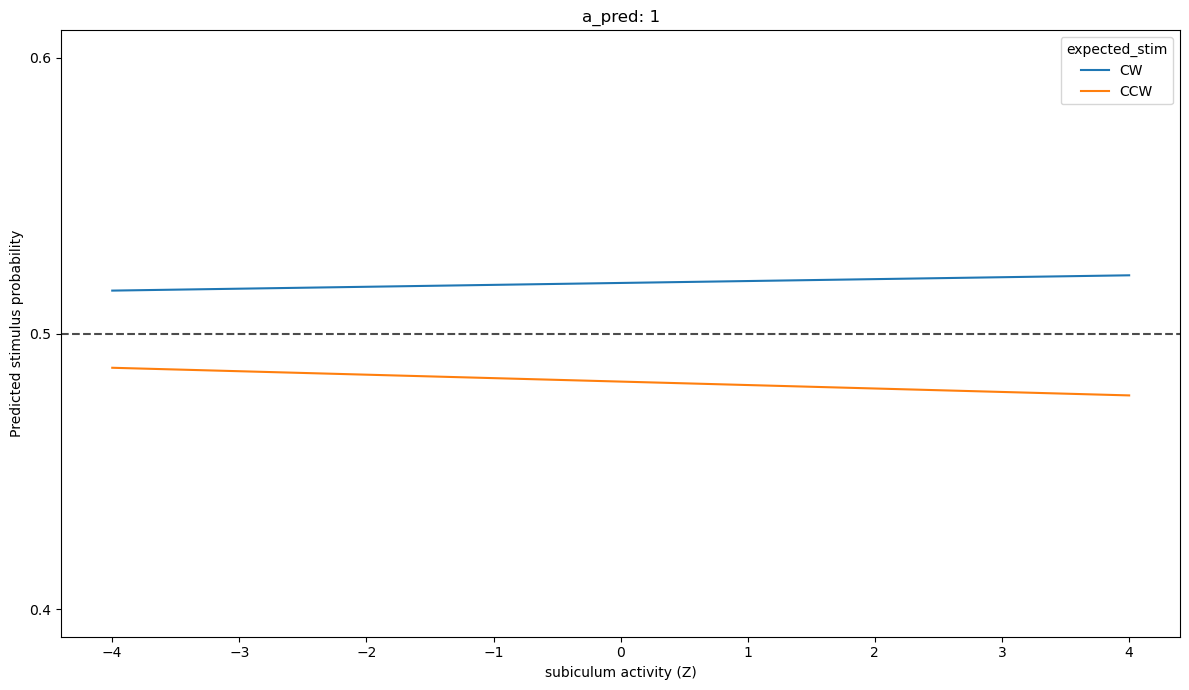

In [13]:
# Create a grid of subplots
fig, axes = plt.subplots(1, 1, figsize=(12, 7))
ax = axes  # Select the specific subplot

sns.lineplot(
    data=predicted_df,
    x=univariate_ROI,
    y="predicted_prob",
    hue="expected_stim",
    ci=None,  # Show standard deviation as confidence interval
    ax=ax
)

ax.axhline(0.5, ls="--", color="black", alpha=0.7)
ax.set_ylim(0.39, .61)  # Set y-axis limits
ax.set_yticks([0.4, 0.5, 0.6])  # Set y-axis ticks
ax.set_ylabel("Predicted stimulus probability")  # Add y-axis label
ax.set_xlabel(f"{univariate_ROI} activity (Z)")  # Add x-axis label
ax.set_title(f'a_pred: 1')  # Add titles

plt.tight_layout()
plt.show()